In [22]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from pathlib import Path

In [23]:
project_path = Path("/Users/irinafendley/Projects/Loan_Default")

df = pd.read_csv(
    project_path / "data/processed/loan_clean.csv"
)

In [24]:
model = joblib.load(
    project_path / "data/models/logistic_regression.pkl"
)

In [25]:
# risky segment definition
risk_group = df[
    (df["CreditScore"] < 400) &
    (df["Income"] < df["Income"].quantile(0.25)) &
    (df["DTIRatio"] > 0.55)
].copy()

In [26]:
risk_group_summary = {
    "Count": len(risk_group),
    "Default_rate_%": risk_group["Default"].mean() * 100,
    "Total_loan": risk_group["LoanAmount"].sum(),
    "Total_loss": (risk_group["LoanAmount"] * risk_group["Default"]).sum()
}

print(risk_group_summary)

{'Count': 5071, 'Default_rate_%': np.float64(20.19325576809308), 'Total_loan': np.int64(645561822), 'Total_loss': np.int64(159711094)}


In [27]:
baseline_default_rate = df["Default"].mean() * 100
baseline_volume = df["LoanAmount"].sum()

print("Baseline default rate:", baseline_default_rate)
print("Baseline volume:", baseline_volume)

Baseline default rate: 11.612824901017047
Baseline volume: 32576880572


In [28]:
rejected_mask = risk_group.index

sim_portfolio = df.drop(index=rejected_mask).copy()

In [29]:
new_default_rate = sim_portfolio["Default"].mean() * 100
new_volume = sim_portfolio["LoanAmount"].sum()

print("After rejection policy:")
print("Default rate:", new_default_rate)
print("Volume:", new_volume)
print("Reduction in volume:", baseline_volume - new_volume)
print("Reduction in default rate:", baseline_default_rate - new_default_rate)

After rejection policy:
Default rate: 11.438971375601337
Volume: 31931318750
Reduction in volume: 645561822
Reduction in default rate: 0.1738535254157103


In [30]:
lost_clients = len(risk_group)
lost_volume = risk_group["LoanAmount"].sum()

print("Rejected clients:", lost_clients)
print("Lost volume:", lost_volume)

Rejected clients: 5071
Lost volume: 645561822


In [31]:
loss_before = (df["LoanAmount"] * df["Default"]).sum()

df_after = df.copy()
df_after.loc[rejected_mask, "LoanAmount"] = 0

loss_after = (df_after["LoanAmount"] * df_after["Default"]).sum()

savings = loss_before - loss_after

savings_pct = savings / loss_before * 100

print(f"Expected default loss for the entire loan portfolio (before policy): ${loss_before:,.0f}")
print(f"Expected default loss for the entire loan portfolio (after rejecting the high-risk segment): ${loss_after:,.0f}")
print(f"Expected loss avoided by the rejection policy: ${savings:,.0f}")
print(f"Reduction in expected portfolio loss: {savings_pct:.2f}%")

Expected default loss for the entire loan portfolio (before policy): $4,285,312,531
Expected default loss for the entire loan portfolio (after rejecting the high-risk segment): $4,125,601,437
Expected loss avoided by the rejection policy: $159,711,094
Reduction in expected portfolio loss: 3.73%


In [32]:
default_rate_before = df["Default"].mean() * 100

sim_portfolio = df.drop(index=rejected_mask)

default_rate_after = sim_portfolio["Default"].mean() * 100

print(f"Portfolio default rate before: {default_rate_before:.2f}%")
print(f"Portfolio default rate after: {default_rate_after:.2f}%")
print(f"Reduction: {default_rate_before - default_rate_after:.2f} percentage points")

Portfolio default rate before: 11.61%
Portfolio default rate after: 11.44%
Reduction: 0.17 percentage points


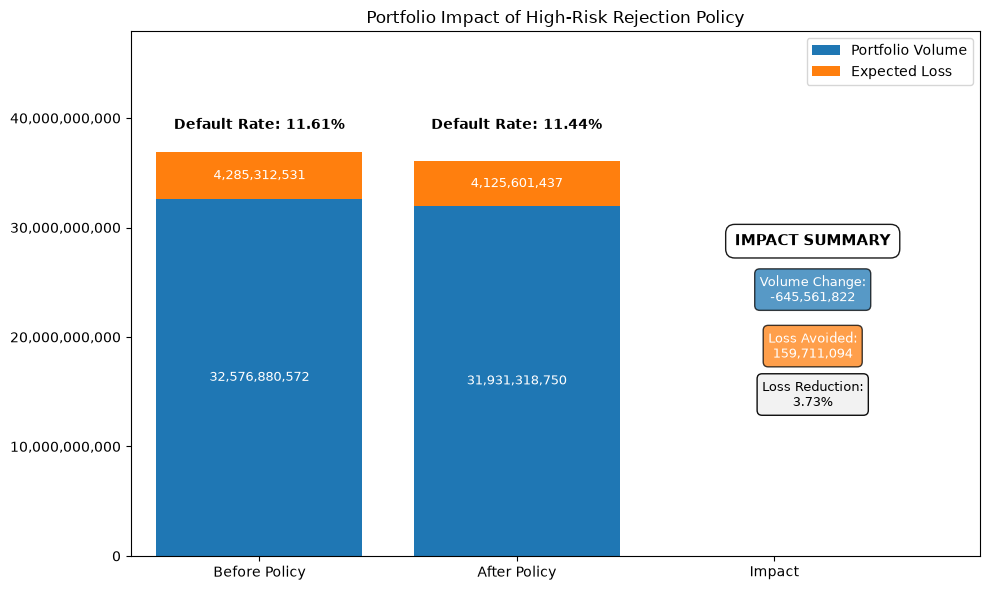

In [44]:

# data
labels = ["Before Policy", "After Policy", "Impact"]

volume_before = 32576880572
volume_after = 31931318750

loss_before = 4285312531
loss_after = 4125601437

# metrics
volume_change = volume_after - volume_before
loss_change = loss_after - loss_before

default_rate_before = 11.61
default_rate_after = 11.44

volume = [volume_before, volume_after, volume_after]
loss = [loss_before, loss_after, loss_after]

x = range(len(labels))

volume_color = "#1f77b4"   
loss_color = "#ff7f0e"    

plt.figure(figsize=(10, 6))

plt.bar(x[0], volume[0], color=volume_color, label="Portfolio Volume")
plt.bar(x[0], loss[0], bottom=volume[0], color=loss_color, label="Expected Loss")

plt.bar(x[1], volume[1], color=volume_color)
plt.bar(x[1], loss[1], bottom=volume[1], color=loss_color)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.ylim(0, (volume_before + loss_before) * 1.3)
plt.xlim(-0.5, 2.8)

for i in [0, 1]:
    plt.text(i, volume[i] / 2,
             f"{volume[i]:,.0f}",
             ha='center', va='center',
             fontsize=9, color='white')

    plt.text(i, volume[i] + loss[i] / 2,
             f"{loss[i]:,.0f}",
             ha='center', va='center',
             fontsize=9, color='white')

plt.text(0, (volume_before + loss_before) * 1.05,
         f"Default Rate: {default_rate_before:.2f}%",
         ha='center', va='bottom',
         fontsize=10, fontweight='bold')

plt.text(1, (volume_before + loss_before) * 1.05,
         f"Default Rate: {default_rate_after:.2f}%",
         ha='center', va='bottom',
         fontsize=10, fontweight='bold')

plt.text(
    2.15, (volume_before + loss_before) * 0.78,
    "IMPACT SUMMARY",
    ha='center',
    va='center',
    fontsize=11,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="black", alpha=0.9)
)

# volume change (blue card)
plt.text(
    2.15, (volume_before + loss_before) * 0.66,
    f"Volume Change:\n{volume_change:,.0f}",
    ha='center', va='center',
    fontsize=9, color="white",
    bbox=dict(boxstyle="round,pad=0.4", facecolor=volume_color, alpha=0.75)
)

# loss avoided (orange card)
plt.text(
    2.15, (volume_before + loss_before) * 0.52,
    f"Loss Avoided:\n{abs(loss_change):,.0f}",
    ha='center', va='center',
    fontsize=9, color="white",
    bbox=dict(boxstyle="round,pad=0.4", facecolor=loss_color, alpha=0.75)
)

# reduction %
plt.text(
    2.15, (volume_before + loss_before) * 0.40,
    f"Loss Reduction:\n{abs(loss_change)/loss_before*100:.2f}%",
    ha='center', va='center',
    fontsize=9,
    color="black",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f2f2f2", alpha=0.95)
)

plt.xticks(x, labels)
plt.title("Portfolio Impact of High-Risk Rejection Policy")
plt.legend()
plt.tight_layout()

# save
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()